### Initialize the Environment:
##### Virtual Environment Commands

| Command | Linux/Mac | GitBash |
| ------- | --------- | ------- |
| Create | `python3 -m venv venv` | `python -m venv venv` |
| Activate | `source venv/bin/activate` | `source venv/Scripts/activate` |
| Install | `pip install -r requirements.txt` | `pip install -r requirements.txt` |
| Deactivate | `deactivate` | `deactivate` |
##### Select the Kernel (This will be in the Requirements.txt eventually)

Using the venv (Python 3.13.2) located  in venv/bin/python)

### **Analysis of the Data**
Capstone Project for Code:You Data Analysis track. This project analyzes Beer Recipes for frequency of uploads for various beer styles, while capturing preferences of strength, hopiness and batch size.    The goal of the project is to demonstrate a general knowledge of Python (Pandas, Numpy, MatLibPlot, Plotly), SQL(MySQL), Tableu, Cursor and ChatGPT.


In [2]:
# pip install openpyxl
# %pip install matplotlib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import random

In [4]:
# Un-pickle the dataframes from Beer_capstone.ipynb
beer_recipes = pd.read_pickle("cleaned_beer_recipes.pkl")
bjcp_style = pd.read_pickle("cleaned_styles_2021.pkl")

In [5]:
# Confirm that data successfully transferred from Beer_capstone.ipynb
print(beer_recipes.info)
print(bjcp_style.info)

<bound method DataFrame.info of                                      Recipe Name                Style  \
0             Avg. Perfect Northeast IPA (NEIPA)             Hazy IPA   
1                   Sierra Nevada Pale Ale Clone    American Pale Ale   
2                              Vanilla Cream Ale            Cream Ale   
3                  Zombie Dust Clone - ALL GRAIN         American IPA   
4       Russian River Pliny The Elder (original)           Double IPA   
...                                          ...                  ...   
236774                                Mild (110)            Dark Mild   
236775                          Simcoe Mild (99)            Dark Mild   
236776         Malted Bliss, Wedding Barley Wine  English Barley Wine   
236777         Malted Bliss, Wedding Barley Wine  English Barley Wine   
236778                   More LPANE Goodness APA    American Pale Ale   

       Style Number     OG  Plato     FG    ABV     IBU Source  \
0               21C  1.06

In [6]:
# Checking combined data for adherence to the 116 Styles in the BJCP 2021 Style Guide
grouped_style = beer_recipes.groupby('Style Number')

grouped_styles = grouped_style.size()
print(grouped_styles)

Style Number
10A    5967
10B    1064
10C     610
11A    2047
11B    2248
       ... 
8A     1024
8B      916
9A      902
9B       57
9C     1056
Length: 115, dtype: int64


### **Data Visualization**

Chart 1: The distribution of the Beer Recipe Styles among the 116 styles. *Highlighting the top 2 styles because of their dominance*.

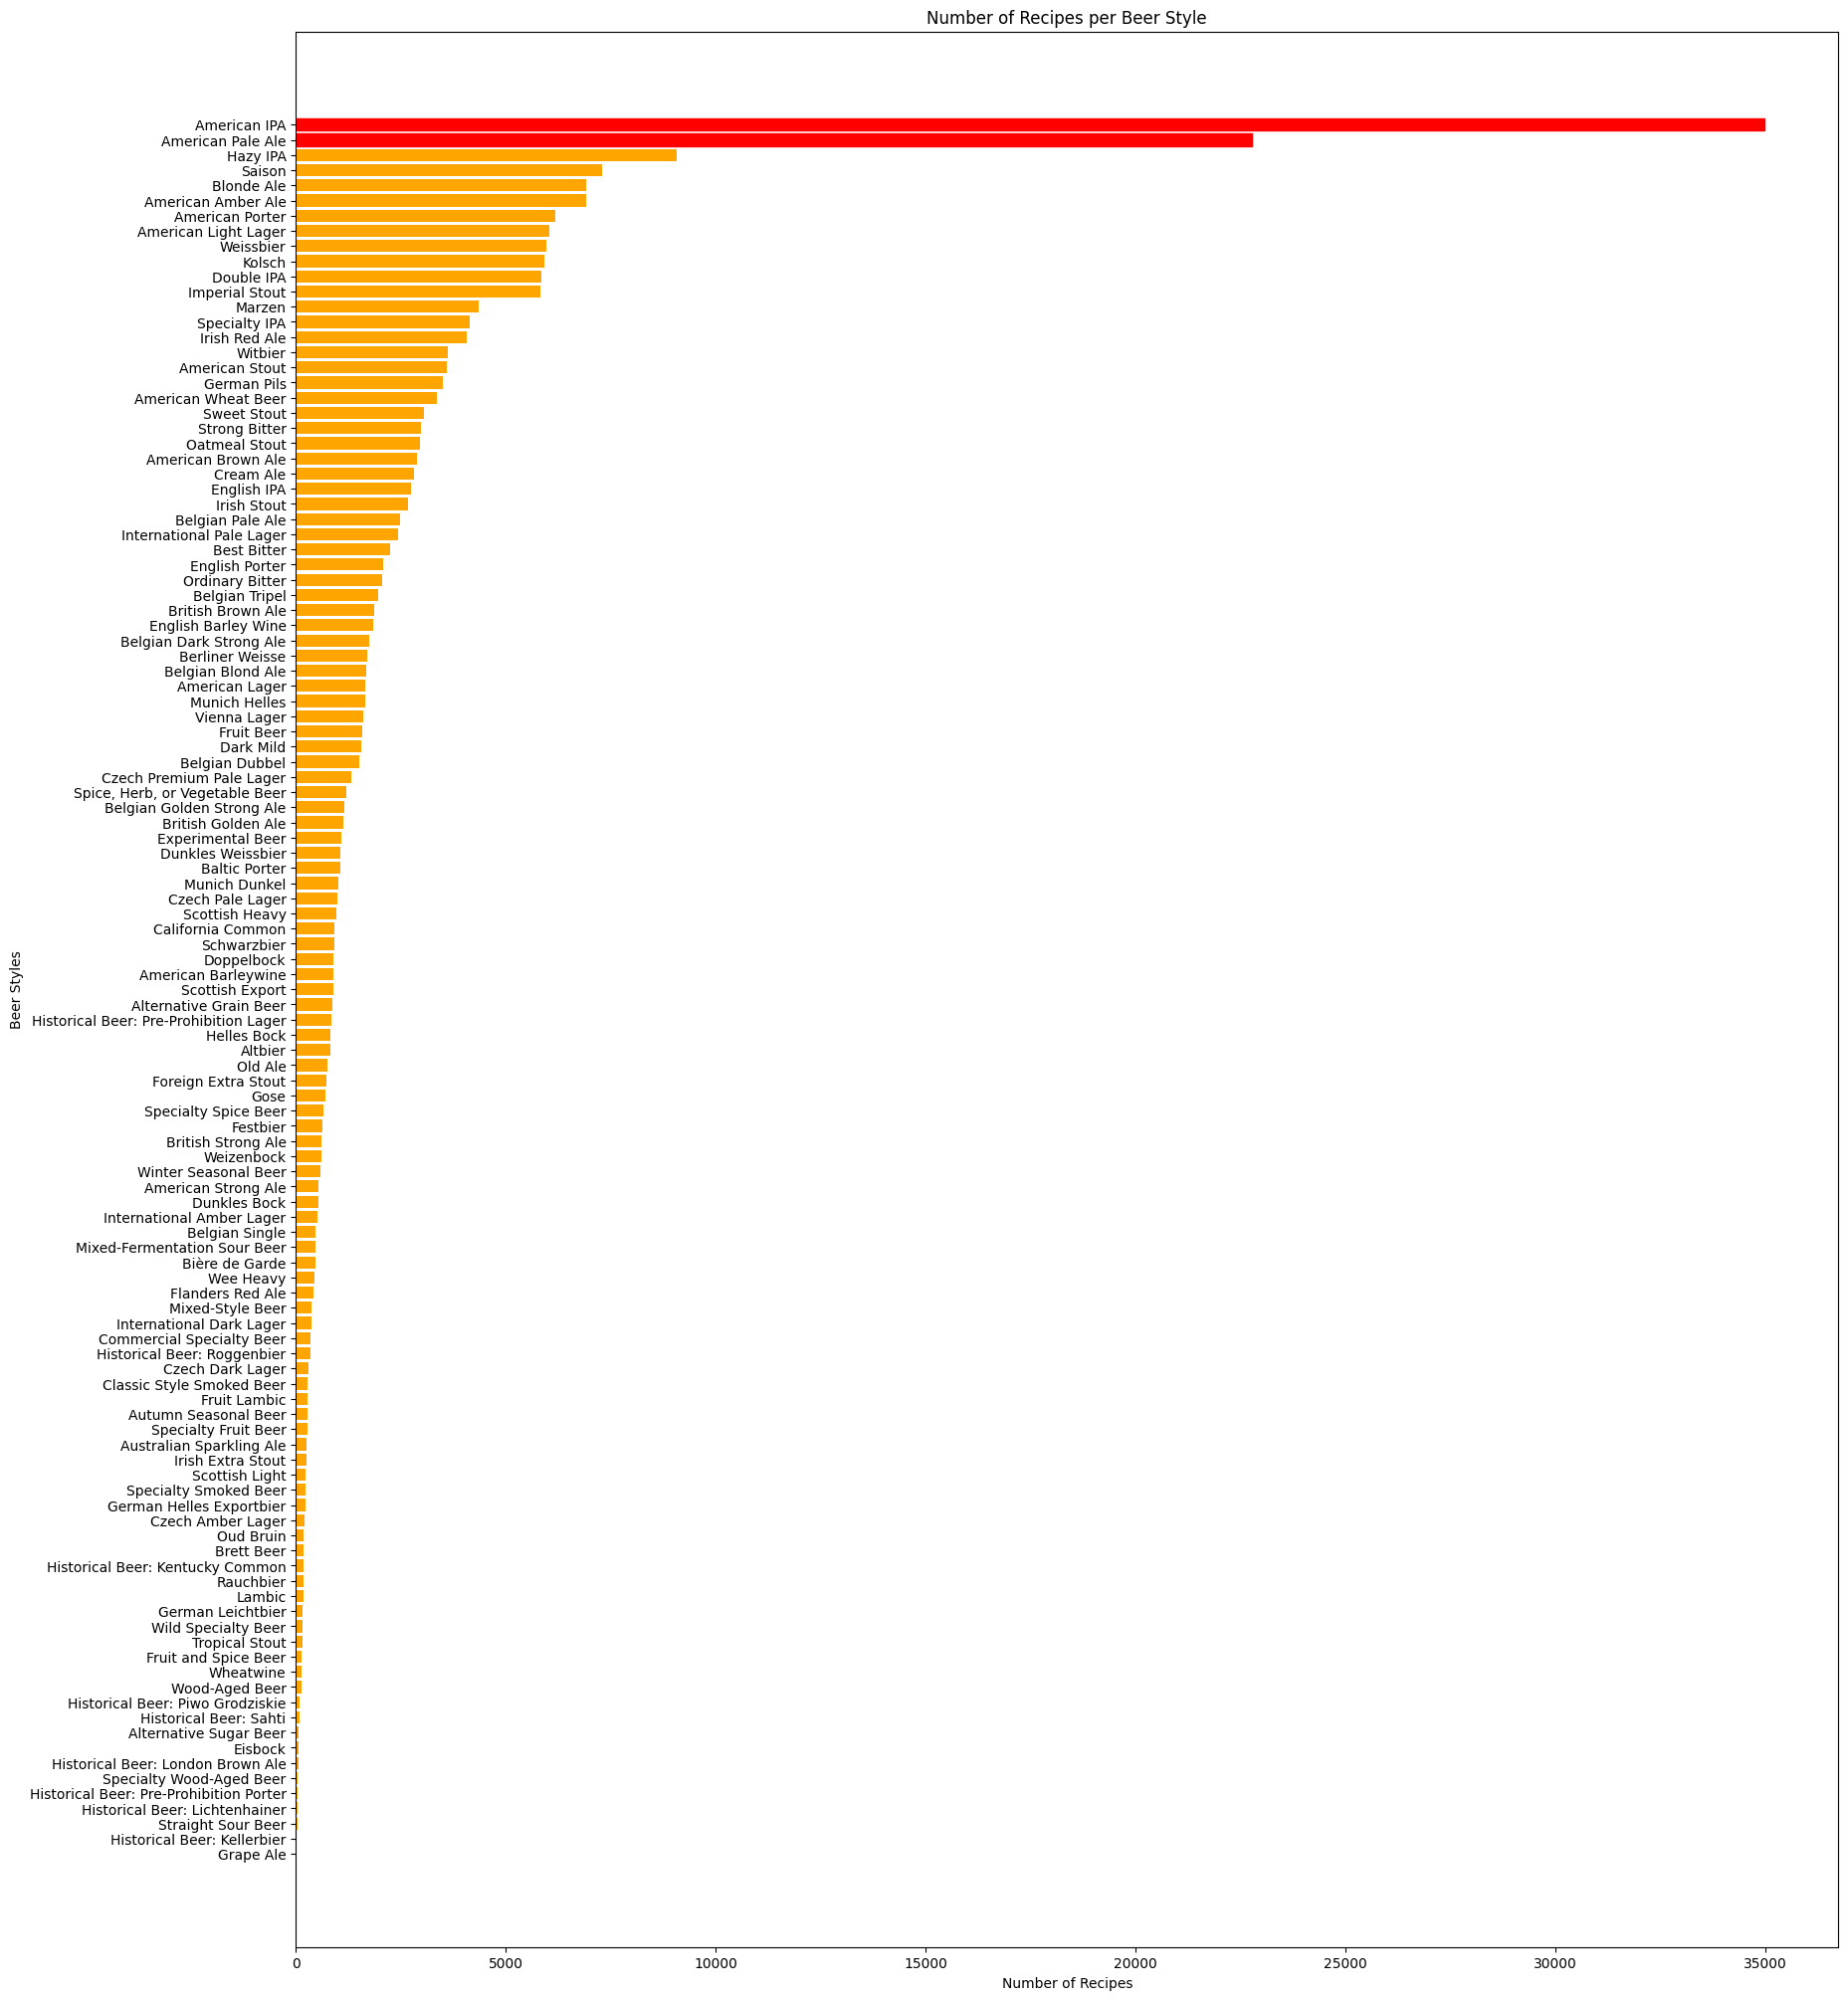

In [7]:
def total_occurrence():
    # Group by 'Style' and count the number of occurrences
    style_counts = beer_recipes['Style'].value_counts()

    # Sort the data in descending order
    style_counts = style_counts.sort_values(ascending=False)
    
    # Plot the bar chart horizontally
    fig, ax = plt.subplots(figsize=(20, 25))
    bars = ax.barh(style_counts.index, style_counts.values, color='orange') # type: ignore

    # Highlight the top 2 bars
    bars[0].set_color('red')
    bars[1].set_color('red')

    plt.xlabel('Number of Recipes')
    plt.ylabel('Beer Styles')
    plt.title('Number of Recipes per Beer Style')
    # Reverse the y-axis to have the largest bars at the top
    ax.invert_yaxis()
    plt.show()

total_occurrence()

Chart 2: The **Top 50** beer styles.

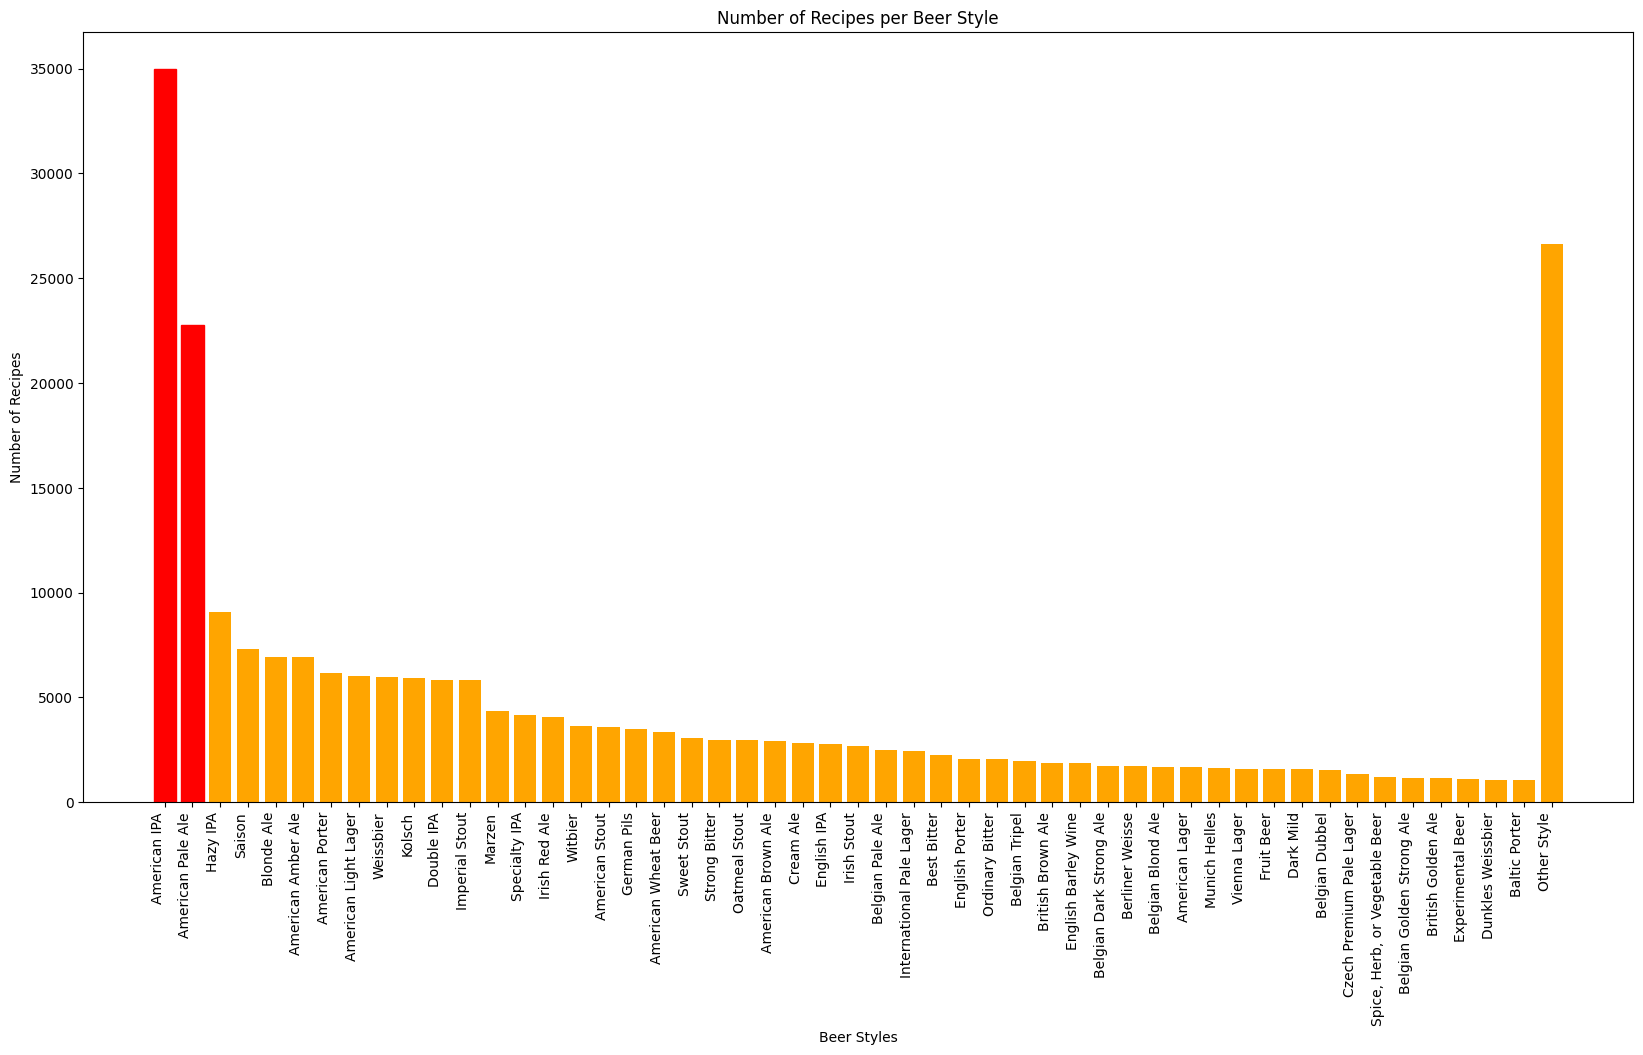

In [8]:
def total_occurrence_abbrev_v():
    # Group by 'Style' and count the number of occurrences
    style_counts = beer_recipes['Style'].value_counts()

    # Sort the data in descending order
    style_counts = style_counts.sort_values(ascending=False)

    # Group the first 50 styles and the rest into "Other Style"
    top_styles = style_counts[:50]
    other_styles = pd.Series([style_counts[50:].sum()], index=['Other Style'])
    style_counts = pd.concat([top_styles, other_styles])

    # Reverse order so largest values appear on the left
    # style_counts = style_counts[::-1]

    # Plot the bar chart vertically
    fig, ax = plt.subplots(figsize=(20, 10))
    bars = ax.bar(style_counts.index, style_counts.values, color='orange')  # type: ignore # Vertical bars

    # Highlight the top 2 bars
    bars[-50].set_color('red')  # Largest value (now at the left)
    bars[-51].set_color('red')

    # Formatting
    plt.ylabel('Number of Recipes')
    plt.xlabel('Beer Styles')
    plt.title('Number of Recipes per Beer Style')

    # Rotate x-axis labels for readability
    plt.xticks(rotation=90, ha='right')

    plt.show()

total_occurrence_abbrev_v()

Chart 3: Number of Recipes per Category

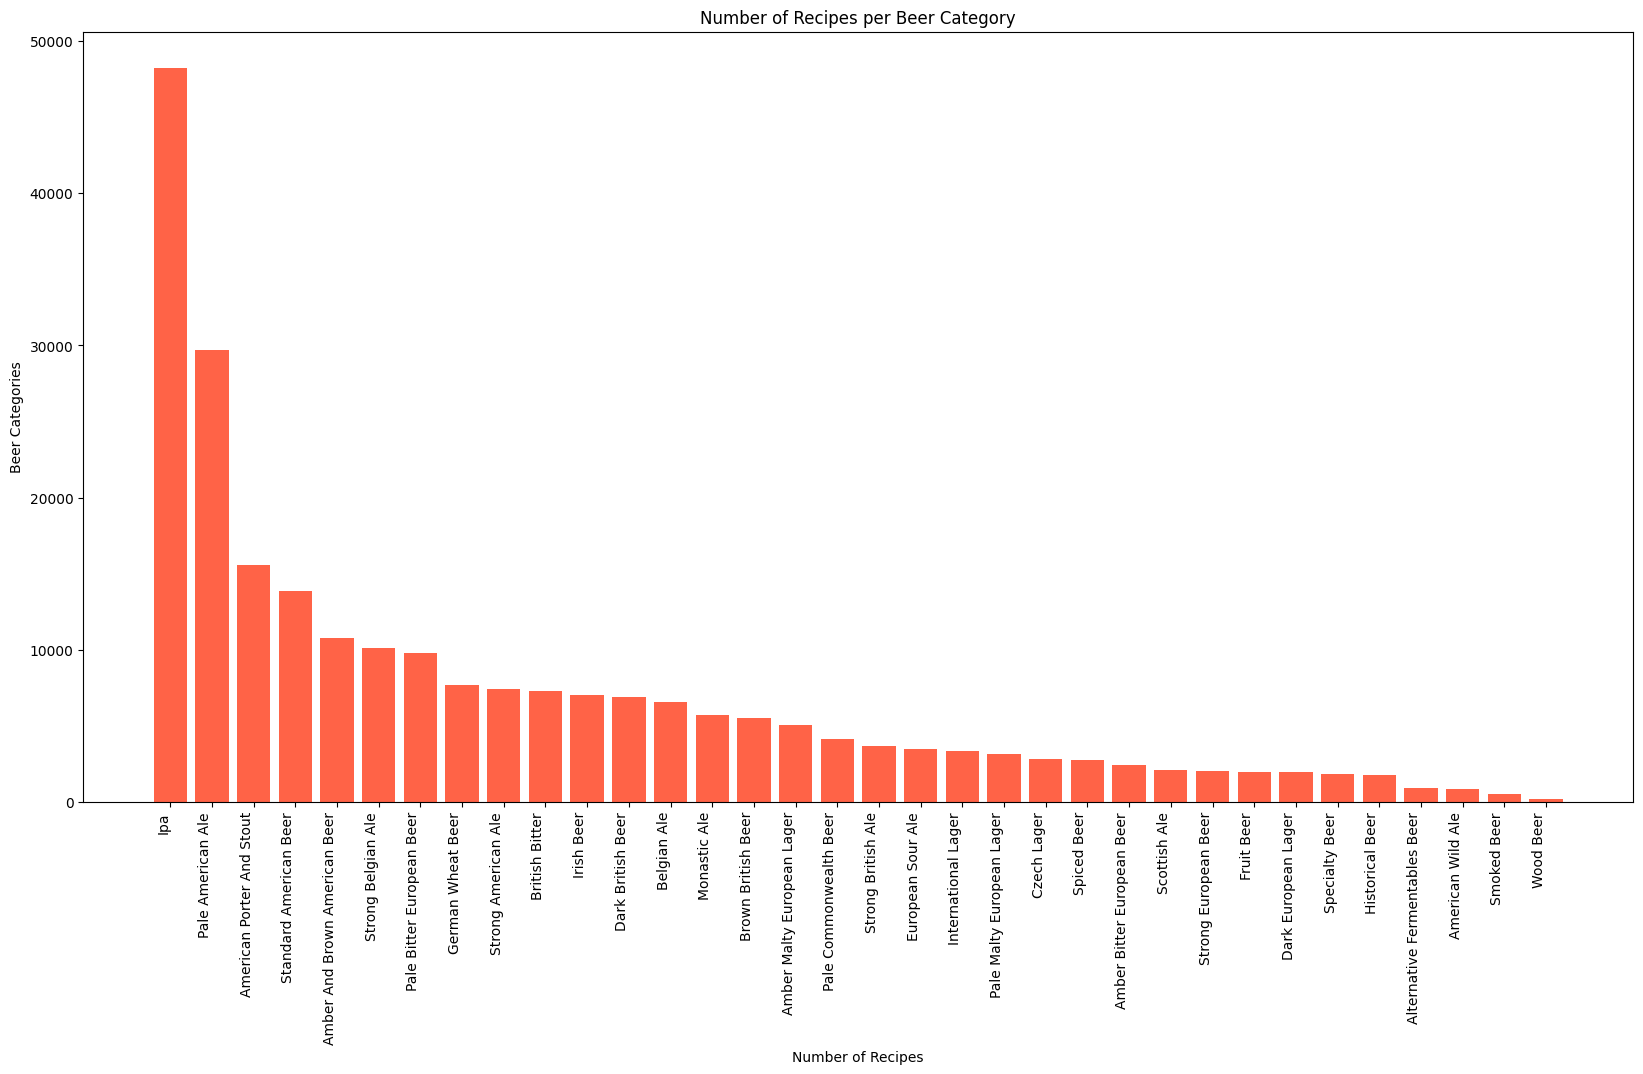

In [9]:
# Group by 'Category' and count the number of occurrences
category_counts = beer_recipes['Category'].value_counts()

# Sort the data in descending order
# category_counts = category_counts.sort_values(ascending=True)

# Plot the bar chart horizontally
fig, ax = plt.subplots(figsize=(20, 10))
bars = ax.bar(category_counts.index, category_counts.values, color='tomato')

plt.xlabel('Number of Recipes')
plt.ylabel('Beer Categories')
plt.title('Number of Recipes per Beer Category')

# Rotate x-axis labels for readability
plt.xticks(rotation=90, ha='right')
    
plt.show()

Chart 4: Stacked bar chart with number of styles in each category

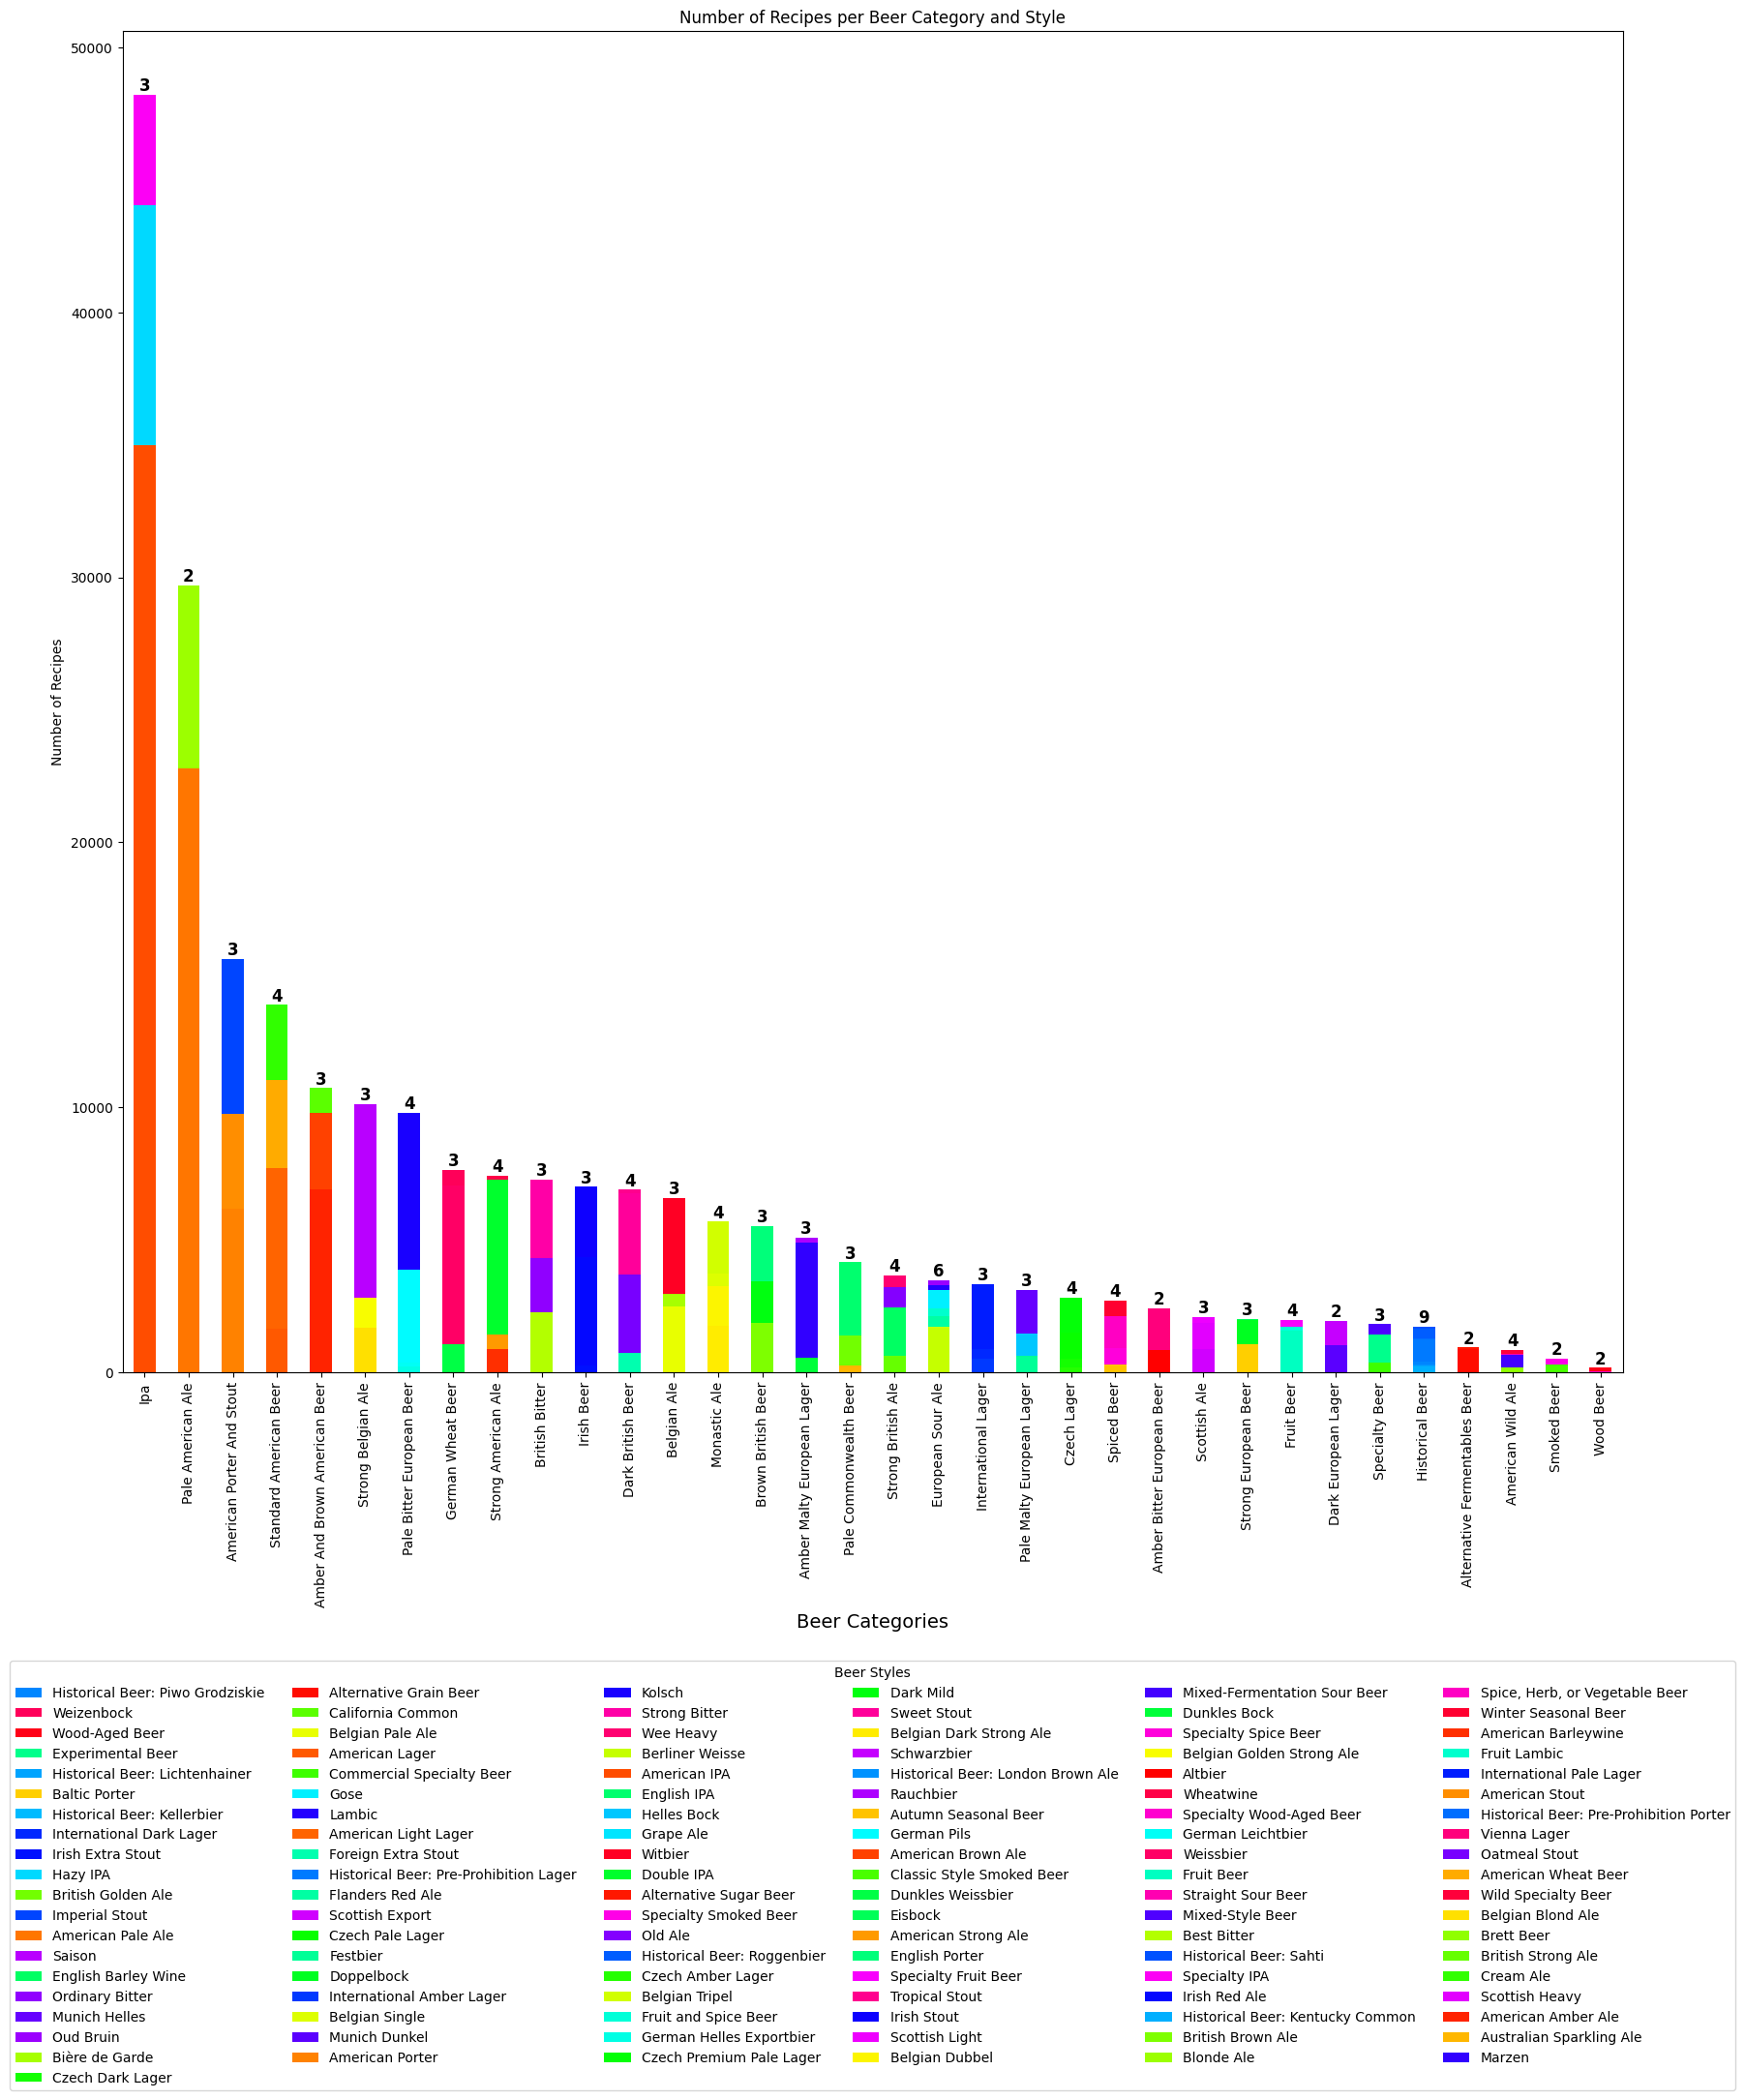

In [10]:
def stack_bar_category():
# Group by 'Category' and 'Style' and count the number of occurrences
    category_style_counts = beer_recipes.groupby(['Category', 'Style']).size().unstack().fillna(0)

# Sort categories by total count (largest first)
    category_style_counts = category_style_counts.loc[category_style_counts.sum(axis=1).sort_values(ascending=False).index]

# Shuffle the style order randomly for the legend
    random.seed(42)
    shuffled_styles = list(category_style_counts.columns)
    random.shuffle(shuffled_styles)

# Plot the stacked bar chart
    fig, ax = plt.subplots(figsize=(20, 18))
    category_style_counts.plot(kind='bar', stacked=True, ax=ax, colormap='hsv')

    plt.xlabel('Beer Categories', fontsize=14)
    plt.ylabel('Number of Recipes')
    plt.title('Number of Recipes per Beer Category and Style')

# Count unique styles per category
    unique_styles_per_category = beer_recipes.groupby('Category')['Style'].nunique()

# Add text annotations above bars
    for i, category in enumerate(category_style_counts.index):
        ax.text(i, category_style_counts.loc[category].sum(), f"{int(unique_styles_per_category.loc[category])}", ha='center', va='bottom', fontsize=12, fontweight='bold')

# Update legend with shuffled order
    handles, labels = ax.get_legend_handles_labels()
    shuffled_handles_labels = sorted(zip(handles, labels), key=lambda x: shuffled_styles.index(x[1]))
    handles, labels = zip(*shuffled_handles_labels)
    ax.legend(handles, labels, title='Beer Styles', bbox_to_anchor=(.5, -0.21), loc='upper center', ncol=6)

    plt.show()

stack_bar_category()

Chart 5: Recipes by Style that meet guidelines for the Style

In [11]:
print(beer_recipes.info())
print(bjcp_style.info())
print(bjcp_style)
print(beer_recipes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236779 entries, 0 to 236778
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Recipe Name   236779 non-null  object 
 1   Style         236779 non-null  object 
 2   Style Number  236779 non-null  object 
 3   OG            236779 non-null  float64
 4   Plato         236779 non-null  float64
 5   FG            236779 non-null  float64
 6   ABV           236779 non-null  float64
 7   IBU           236779 non-null  float64
 8   Source        236779 non-null  object 
 9   Category      236779 non-null  object 
dtypes: float64(5), object(5)
memory usage: 18.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Style           116 non-null    object 
 1   Style Number    116 non-null    object 
 2   Category     

In [ ]:
def check_recipe_compliance(beer_recipes, bjcp_style):
    # Remove styles with missing FG values from bjcp_style
    valid_styles = bjcp_style.dropna(subset=['fgmin', 'fgmax'])
    
    # Initialize results dictionary
    results = []
    
    # Process only recipes that have a style in our valid_styles
    valid_recipes = beer_recipes[beer_recipes['Style'].isin(valid_styles['Style'])]
    
    for _, recipe in valid_recipes.iterrows():
        style_guide = valid_styles[valid_styles['Style'] == recipe['Style']].iloc[0]
        
        # Check each requirement
        og_compliant = style_guide['ogmin'] <= recipe['OG'] <= style_guide['ogmax']
        fg_compliant = style_guide['fgmin'] <= recipe['FG'] <= style_guide['fgmax']
        abv_compliant = style_guide['abvmin'] <= recipe['ABV'] <= style_guide['abvmax']
        ibu_compliant = style_guide['ibumin'] <= recipe['IBU'] <= style_guide['ibumax']
        
        # Count total compliant metrics
        total_compliant = sum([og_compliant, fg_compliant, abv_compliant, ibu_compliant])
        
        results.append({
            'Style': recipe['Style'],
            'Total_Compliant': total_compliant,
            'OG_Compliant': og_compliant,
            'FG_Compliant': fg_compliant,
            'ABV_Compliant': abv_compliant,
            'IBU_Compliant': ibu_compliant
        })
    
    return pd.DataFrame(results)

# Create compliance DataFrame
compliance_df = check_recipe_compliance(beer_recipes, bjcp_style)

# Create summary table
summary_table = pd.DataFrame()

# Calculate metrics per style
for style in compliance_df['Style'].unique():
    style_data = compliance_df[compliance_df['Style'] == style]
    
    # Calculate counts for total compliance levels
    compliance_counts = pd.Series({
        'Total_Recipes': len(style_data),
        'Met_All_Requirements': sum(style_data['Total_Compliant'] == 4),
        'Met_3_Requirements': sum(style_data['Total_Compliant'] == 3),
        'Met_2_Requirements': sum(style_data['Total_Compliant'] == 2),
        'Met_1_Requirement': sum(style_data['Total_Compliant'] == 1),
        'Met_No_Requirements': sum(style_data['Total_Compliant'] == 0),
        'OG_Compliant': sum(style_data['OG_Compliant']),
        'FG_Compliant': sum(style_data['FG_Compliant']),
        'ABV_Compliant': sum(style_data['ABV_Compliant']),
        'IBU_Compliant': sum(style_data['IBU_Compliant'])
    })
    
    summary_table = pd.concat([summary_table, pd.DataFrame(compliance_counts).T], axis=0)

summary_table.index = compliance_df['Style'].unique() # type: ignore

# Display the summary table
print("\nCompliance Summary Table:")
print(summary_table)


Compliance Summary Table:
                                   Total_Recipes  Met_All_Requirements  \
Hazy IPA                                    9066                  1556   
American Pale Ale                          22776                  8619   
Cream Ale                                   2818                   923   
American IPA                               34996                  6525   
Double IPA                                  5845                  1275   
...                                          ...                   ...   
Eisbock                                       57                    12   
Historical Beer: London Brown Ale             54                     6   
German Leichtbier                            162                    25   
Grape Ale                                      1                     0   
Straight Sour Beer                            38                     0   

                                   Met_3_Requirements  Met_2_Requirements  \
Hazy IP